# Various utility functions for multi cam marker tracking

## mov2png Converter
Lazy script to convert .MOV video files into individual frame images saved as .png files

In [1]:
import os
import cv2
import numpy as np
from cv2 import aruco
from PIL import Image

# image_path = '/Users/E135086/Documents/playground/testPhotos_29062026/'
indir = '/Users/E135086/Movies/20260710_trackStream/'
inCams = ['builtin', 'othermac', 'logi', 'iphone']
camNum = 0
outdir = '/Users/E135086/Documents/playground/data_multiview/20260710_trackStream/'

for n, cam in enumerate(inCams):
    outcamdir = outdir + str(n) + '/'
    os.makedirs(outcamdir, exist_ok=True)

    cap = cv2.VideoCapture(indir+cam+'.mov')
    if not cap.isOpened():
        print("Error opening video stream or file")
        exit()
    else:
        print(f"Processing camera {cam}...")
        frame_count = 0
        while True:
            ret, frame = cap.read()
            frame_count += 1
            if not ret:
                break
            cv2.imwrite(outcamdir+f'{frame_count}.png', frame)


cap.release()
cv2.destroyAllWindows()

Processing camera builtin...
Processing camera othermac...
Processing camera logi...
Processing camera iphone...


## Reading Solution and Calc Abs Distance

In [ ]:
import yaml, numpy as np

indir = '/Users/E135086/Documents/playground/testPhotos_29062026/MOV2PNG/'

with open(indir+'final.solution.yaml') as f:
    sol = yaml.safe_load(f)

for entry in sol['transforms_to_root_marker']:
    mid = entry['marker_id']
    T   = np.array(entry['transform'])
    dist = np.linalg.norm(T[:3, 3])
    print(f'Marker {mid}: distance from root = {dist:.4f} m')

Marker 9: distance from root = 0.0000 m
Marker 10: distance from root = 0.0503 m
Marker 11: distance from root = 0.0502 m


# Read and plot marker tracking results

In [4]:
import csv
import numpy as np

infile = '/Users/E135086/Documents/playground/data_multiview/20260710_trackStream/marker_distance_history.csv'
series = {}
reference_marker_id = None

with open(infile, 'r', newline='') as f:
    reader = csv.DictReader(f)
    required = {'frame_num', 'reference_marker_id', 'marker_id', 'distance_m'}
    missing = required - set(reader.fieldnames or [])
    if missing:
        raise ValueError(
            f'CSV is missing required columns: {", ".join(sorted(missing))}'
        )

    for row in reader:
        frame_num = int(row['frame_num'])
        marker_id = int(row['marker_id'])
        ref_raw = row['reference_marker_id'].strip()
        if ref_raw:
            reference_marker_id = int(ref_raw)
        dist_raw = row['distance_m'].strip()
        if not dist_raw:
            continue
        distance = float(dist_raw)
        if np.isnan(distance):
            continue
        series.setdefault(marker_id, []).append((frame_num, distance))

for marker_id in series:
    series[marker_id].sort(key=lambda p: p[0])

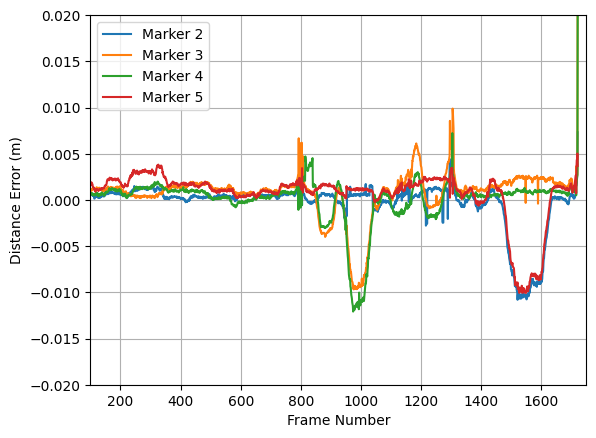

In [ ]:
import matplotlib.pyplot as plt

expected_distance = 0.07
for key, val in series.items():
    frames, dists = zip(*val)
    plt.plot(frames, np.array(dists)-expected_distance, label=f'Marker {key+1}')

plt.xlabel('Frame Number')
plt.ylabel('Distance Error (m)')
plt.legend()
plt.xlim([100,1750])
plt.ylim([-0.02, 0.02])
plt.grid()